In [ ]:
import numpy as np
import pandas as pd

df = pd.read_json("E:/Downloads/games.json")

# transpose the dataframe since the JSON is keyed by AppID
df = df.T

# restore AppID from index and reset it
df = df.reset_index(names='AppID')

# convert genres (list) and tags (dict) to comma-separated strings for compatibility
if 'genres' in df.columns:
    df['genres'] = df['genres'].apply(lambda x: ','.join(x) if isinstance(x, list) else x)
if 'tags' in df.columns:
    df['tags'] = df['tags'].apply(lambda x: ','.join(x.keys()) if isinstance(x, dict) else x)

# Convert any remaining list/dict columns (like screenshots, movies, etc.) to strings for SQLite compatibility
for col in df.columns:
    if df[col].apply(lambda x: isinstance(x, (list, dict))).any():
        df[col] = df[col].apply(lambda x: str(x) if isinstance(x, (list, dict)) else x)

# rename columns to match the expected names used in the analysis
column_mapping = {
    'name': 'Name',
    'release_date': 'Release date',
    'estimated_owners': 'Estimated owners',
    'peak_ccu': 'Peak CCU',
    'required_age': 'Required age',
    'price': 'Price',
    'discount': 'Discount',
    'dlc_count': 'DLC count',
    'about_the_game': 'About the game',
    'supported_languages': 'Supported languages',
    'full_audio_languages': 'Full audio languages',
    'reviews': 'Reviews',
    'header_image': 'Header image',
    'website': 'Website',
    'support_url': 'Support url',
    'support_email': 'Support email',
    'windows': 'Windows',
    'mac': 'Mac',
    'linux': 'Linux',
    'metacritic_score': 'Metacritic score',
    'metacritic_url': 'Metacritic url',
    'user_score': 'User score',
    'positive': 'Positive',
    'negative': 'Negative',
    'score_rank': 'Score rank',
    'achievements': 'Achievements',
    'recommendations': 'Recommendations',
    'notes': 'Notes',
    'average_playtime_forever': 'Average playtime forever',
    'average_playtime_2weeks': 'Average playtime two weeks',
    'median_playtime_forever': 'Median playtime forever',
    'median_playtime_2weeks': 'Median playtime two weeks',
    'developers': 'Developers',
    'publishers': 'Publishers',
    'categories': 'Categories',
    'genres': 'Genres',
    'tags': 'Tags',
    'screenshots': 'Screenshots',
    'movies': 'Movies'
}

df = df.rename(columns=column_mapping)

df.head()

,AppID,Name,Release date,Required age,Price,DLC count,detailed_description,About the game,short_description,Reviews,...,Positive,Negative,Estimated owners,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Discount,Peak CCU,Tags
0,1964380,My little sister: Prologue,"May 13, 2022",0,0.0,0,"Synopsis Suhan, a high school student, feels f...","Synopsis Suhan, a high school student, feels f...",😒😐🤨😉🥰😨😈 The girl of my dreams,,...,0,0,0 - 20000,0,0,0,0,0,0,[]
1,1840920,SEARCH ALL - FOXES,"Dec 20, 2021",0,2.99,0,SEARCH ALL - FOXES is a game in the genre of '...,SEARCH ALL - FOXES is a game in the genre of '...,"Is a game in the genre of 'hidden object', in ...",,...,99,8,20000 - 50000,0,0,0,0,80,0,"Exploration,Trading Card Game,Flight,Clicker,C..."
2,1591670,Mark & Lara: Partners In Justice,"Apr 16, 2021",0,4.99,0,A CO-OP DETECTIVE EXPERIENCE. An adventure for...,A CO-OP DETECTIVE EXPERIENCE. An adventure for...,Call your partner and become the best detectiv...,,...,51,8,0 - 20000,0,0,0,0,0,0,"Online Co-Op,Co-op,Co-op Campaign,Local Co-Op,..."
3,2624950,Welcome to the Karoshi Club,"Dec 27, 2023",0,0.0,2,Karoshi Club About the Game 'Welcome to the Ka...,'Welcome to the Karoshi Club' is a free visual...,If you're nervous about job searching and inte...,“But what would you rather do? Rest on your mo...,...,0,0,0 - 0,0,0,0,0,0,0,[]
4,2102530,Mega Fast Food: A Fast Food Simulator Game,"Feb 3, 2024",0,13.99,0,"Wishlist Now About the Game Mega Fast Food , i...","Mega Fast Food , is a simulation management ga...",Build and manage your own fast food store. Dec...,,...,3,16,0 - 20000,0,0,0,0,0,0,"Simulation,Management,City Builder,Building,Sa..."


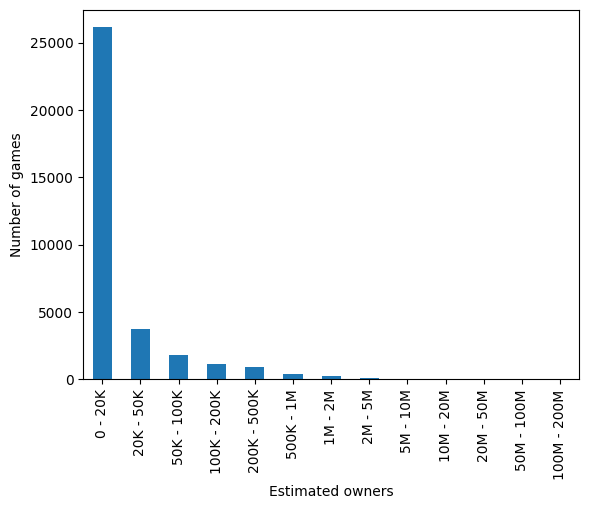

In [ ]:
df = df[df['Estimated owners'] != '0 - 0'] # Remove the rows with no owners.

# map the original long strings to shorter 'K' labels
owner_label_map = {
    '0 - 20000': '0 - 20K', 
    '20000 - 50000': '20K - 50K', 
    '50000 - 100000': '50K - 100K', 
    '100000 - 200000': '100K - 200K', 
    '200000 - 500000': '200K - 500K', 
    '500000 - 1000000': '500K - 1M', 
    '1000000 - 2000000': '1M - 2M', 
    '2000000 - 5000000': '2M - 5M', 
    '5000000 - 10000000': '5M - 10M', 
    '10000000 - 20000000': '10M - 20M', 
    '20000000 - 50000000': '20M - 50M', 
    '50000000 - 100000000': '50M - 100M', 
    '100000000 - 200000000': '100M - 200M'
}

# apply the new labels
df['Estimated owners'] = df['Estimated owners'].map(owner_label_map)

# define the logical order for the new 'K' labels
owner_order_k = list(owner_label_map.values())

# create a mapping of owner range to a numeric rank for sorting
owner_rank_map = {val: i for i, val in enumerate(owner_order_k)}
df['owners_rank'] = df['Estimated owners'].map(owner_rank_map)

df['Estimated owners'].value_counts().plot.bar(ylabel='Number of games');

In [ ]:
import sqlite3

# connect to SQLite database (or create it if it doesn't exist)
conn = sqlite3.connect('steam_games.db')

# save the dataframe to a table named 'cleaned_games'
df.to_sql('cleaned_games', conn, if_exists='replace', index=False)

conn.close()